In [1]:
%matplotlib inline
## Load tfmodisco results from the full-library run, per cell line; recompute (lfc, cossim).
import os, sys, json, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT  = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
CTS = ['HepG2', 'K562']

MODISCO_H5  = lambda ct: os.path.join(REPO, 'genomic_targets/data/modisco',
                                      f'{ct}_full56k_enh230_default.h5')
HITS_TSV    = lambda ct: os.path.join(REPO, 'genomic_targets/data/motif', ct, 'hits.tsv')
TOMTOM_JSON = os.path.join(REPO, 'genomic_targets/data/modisco',
                           'tomtom_jaspar2026_full56k_enh230_default.json')

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{c}_log2FC' for c in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets/data/deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{c}_log2FC' for c in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct]   = hyp
    em.attr[ct]       = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values

modisco = {}
for ct in CTS:
    with h5py.File(MODISCO_H5(ct)) as f:
        n_pos = len(f['pos_patterns']) if 'pos_patterns' in f else 0
        n_neg = len(f['neg_patterns']) if 'neg_patterns' in f else 0
    modisco[ct] = {'h5': MODISCO_H5(ct), 'n_pos': n_pos, 'n_neg': n_neg}

summary = pd.DataFrame([{'ct': ct, **{k: v for k, v in modisco[ct].items() if k != 'h5'}}
                        for ct in CTS])
print(f'{len(df)} seqs')
print(summary.to_string(index=False))

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs
   ct  n_pos  n_neg
HepG2     31      4
 K562     29     11


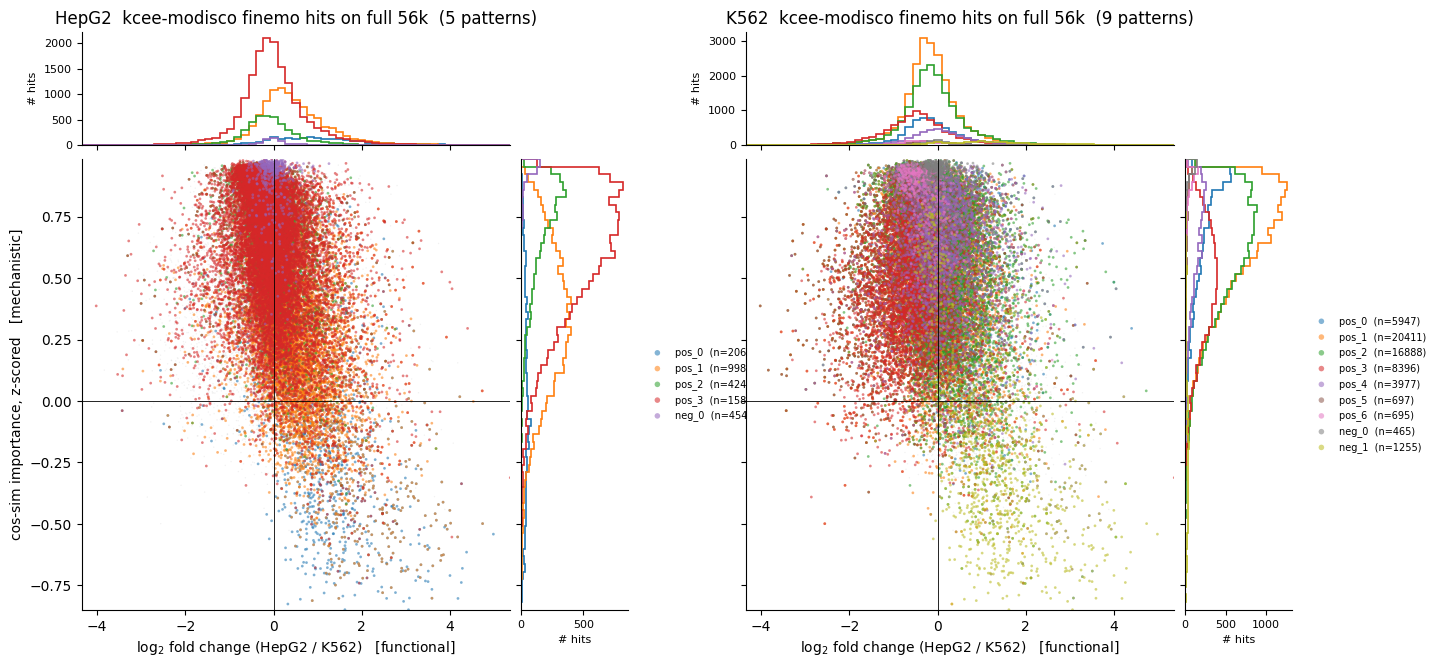

In [6]:
## kcee-modisco finemo hits across the full 56k library, per ct, colored per pattern. Raw-count marginals.
KCEE_HITS = lambda ct: os.path.join(REPO, 'genomic_targets/data/modisco/finemo_compare',
                                    f'kcee_{ct}', 'hits.tsv')

n   = len(df)
fin = np.isfinite(lfc) & np.isfinite(cossim)
x_lim = (np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]))
y_lim = (np.nanmin(cossim[fin]), np.nanmax(cossim[fin]))
x_bins_h = np.linspace(*x_lim, 60); y_bins_h = np.linspace(*y_lim, 60)

def hits_df(ct):
    h = pd.read_csv(KCEE_HITS(ct), sep='\t', usecols=['peak_id', 'motif_name'])
    h['peak_id'] = h['peak_id'].astype(int)
    return h[h['peak_id'] < n]

def pat_key(m):
    grp, pat = m.split('.')
    return (0 if grp.startswith('pos') else 1, int(pat.split('_')[-1]))

fig = plt.figure(figsize=(17, 7.5))
gs  = fig.add_gridspec(2, 6,
                       width_ratios=[4, 1, 0.9, 4, 1, 0.9],
                       height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

scatter_axes = []
for col, ct in zip([0, 3], CTS):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    h = hits_df(ct)
    motifs = sorted(h['motif_name'].unique(), key=pat_key)
    cmap = plt.get_cmap('tab10')
    for i, mname in enumerate(motifs):
        ids = h.loc[h['motif_name'] == mname, 'peak_id'].values
        ids = ids[ids < n]
        m = np.zeros(n, dtype=bool); m[ids] = True; m &= fin
        if m.sum() < 1: continue
        c = cmap(i % cmap.N)
        ax_main.scatter(lfc[m], cossim[m], s=4, color=c, alpha=0.55,
                        edgecolors='none', rasterized=True,
                        label=f'{mname.replace("_patterns.pattern", "")}  (n={m.sum()})')
        if m.sum() >= 2:
            ax_top.hist(lfc[m],   bins=x_bins_h, color=c,
                        histtype='step', linewidth=1.2)
            ax_rt.hist(cossim[m], bins=y_bins_h, color=c,
                       histtype='step', linewidth=1.2, orientation='horizontal')

    ax_main.axhline(0, color='k', lw=0.6); ax_main.axvline(0, color='k', lw=0.6)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=7, loc='center left',
                   bbox_to_anchor=(1.30, 0.5), markerscale=2, ncol=1)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(f'{ct}  kcee-modisco finemo hits on full 56k  ({len(motifs)} patterns)')
    ax_top.set_ylabel('# hits', fontsize=8)
    ax_rt.set_xlabel('# hits', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
plt.show()

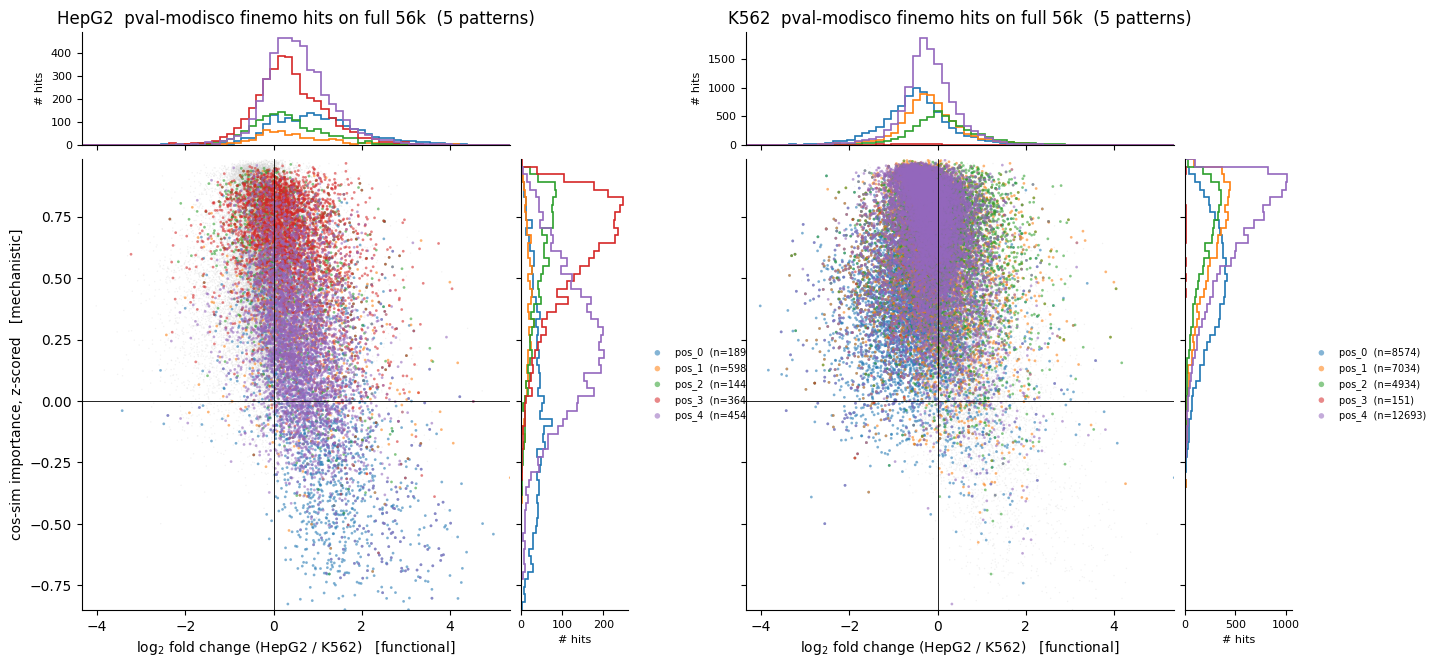

In [8]:
## pval-modisco finemo hits across the full 56k library, per ct, colored per pattern. Raw-count marginals.
PVAL_HITS = lambda ct: os.path.join(REPO, 'genomic_targets/data/modisco/finemo_compare',
                                    f'pval_{ct}', 'hits.tsv')

def hits_df_pval(ct):
    h = pd.read_csv(PVAL_HITS(ct), sep='\t', usecols=['peak_id', 'motif_name'])
    h['peak_id'] = h['peak_id'].astype(int)
    return h[h['peak_id'] < n]

fig = plt.figure(figsize=(17, 7.5))
gs  = fig.add_gridspec(2, 6,
                       width_ratios=[4, 1, 0.9, 4, 1, 0.9],
                       height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

scatter_axes = []
for col, ct in zip([0, 3], CTS):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    h = hits_df_pval(ct)
    motifs = sorted(h['motif_name'].unique(), key=pat_key)
    cmap = plt.get_cmap('tab10')
    for i, mname in enumerate(motifs):
        ids = h.loc[h['motif_name'] == mname, 'peak_id'].values
        ids = ids[ids < n]
        m = np.zeros(n, dtype=bool); m[ids] = True; m &= fin
        if m.sum() < 1: continue
        c = cmap(i % cmap.N)
        ax_main.scatter(lfc[m], cossim[m], s=4, color=c, alpha=0.55,
                        edgecolors='none', rasterized=True,
                        label=f'{mname.replace("_patterns.pattern", "")}  (n={m.sum()})')
        if m.sum() >= 2:
            ax_top.hist(lfc[m],   bins=x_bins_h, color=c,
                        histtype='step', linewidth=1.2)
            ax_rt.hist(cossim[m], bins=y_bins_h, color=c,
                       histtype='step', linewidth=1.2, orientation='horizontal')

    ax_main.axhline(0, color='k', lw=0.6); ax_main.axvline(0, color='k', lw=0.6)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=7, loc='center left',
                   bbox_to_anchor=(1.30, 0.5), markerscale=2, ncol=1)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(f'{ct}  pval-modisco finemo hits on full 56k  ({len(motifs)} patterns)')
    ax_top.set_ylabel('# hits', fontsize=8)
    ax_rt.set_xlabel('# hits', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
plt.show()

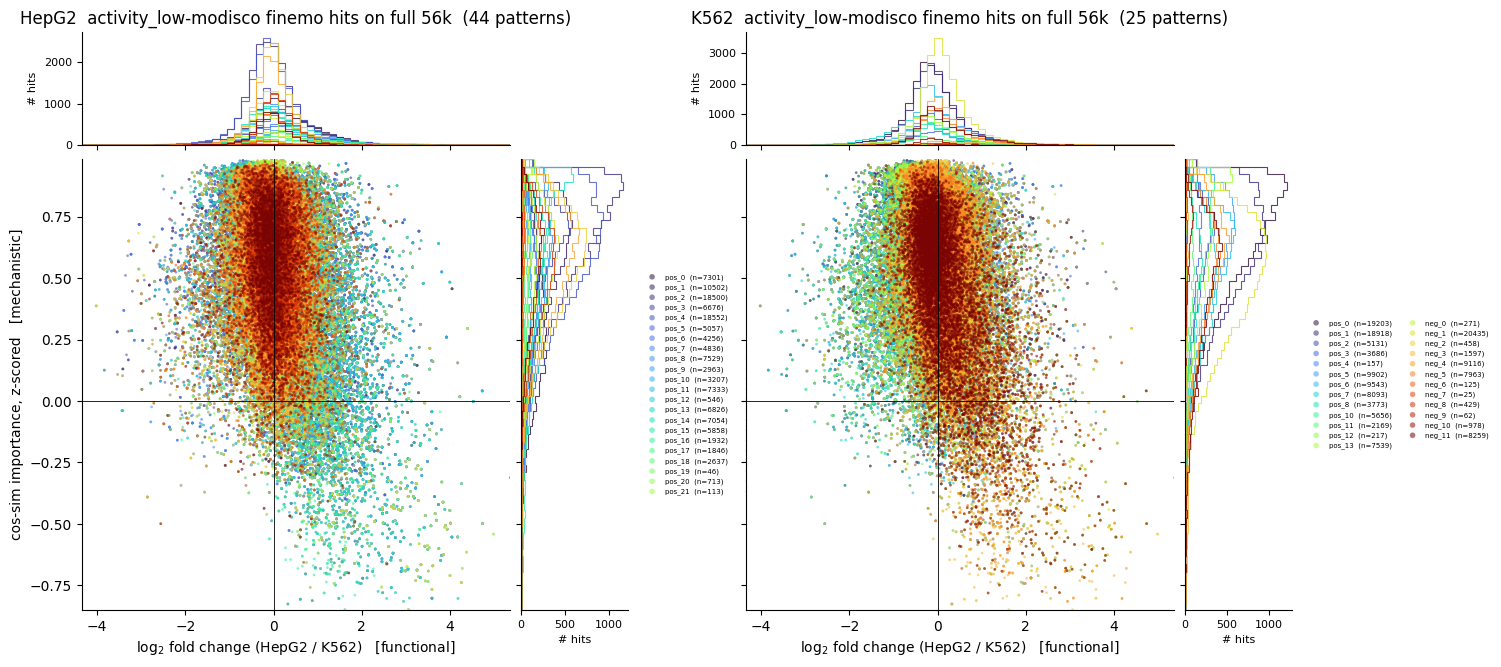

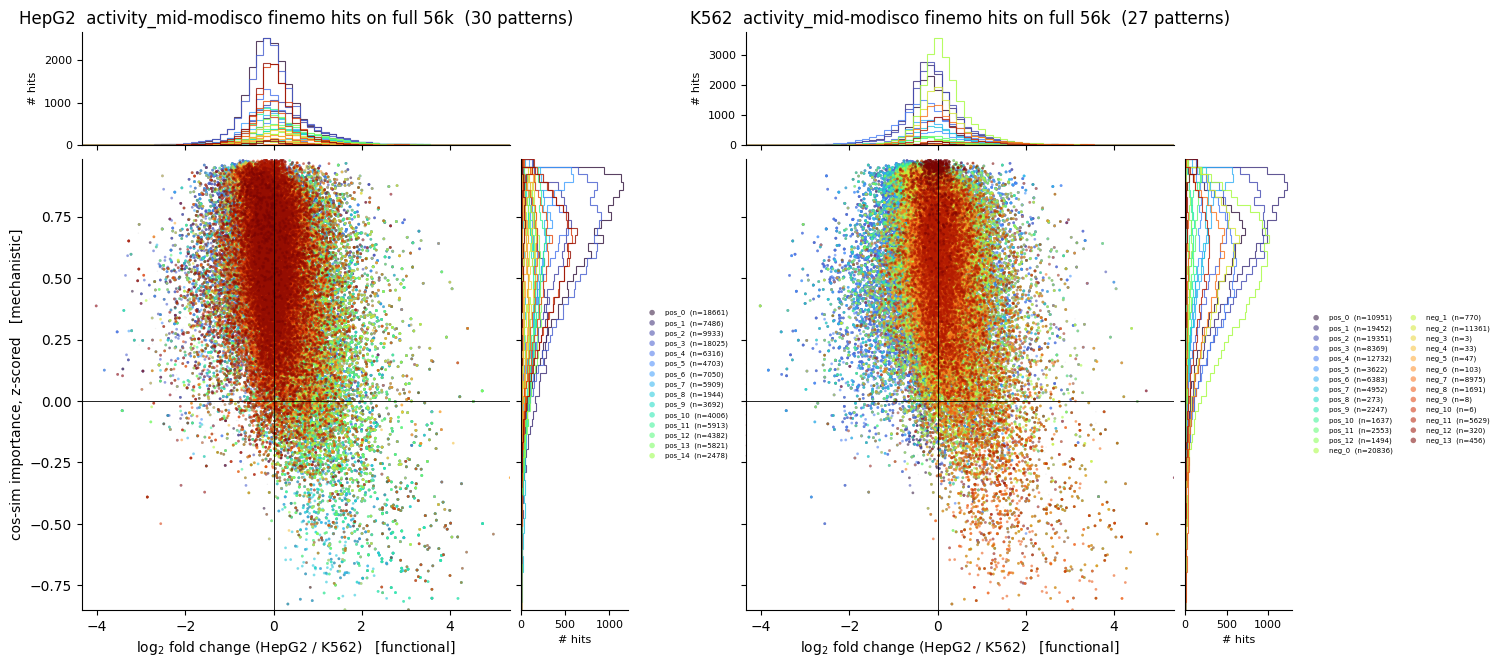

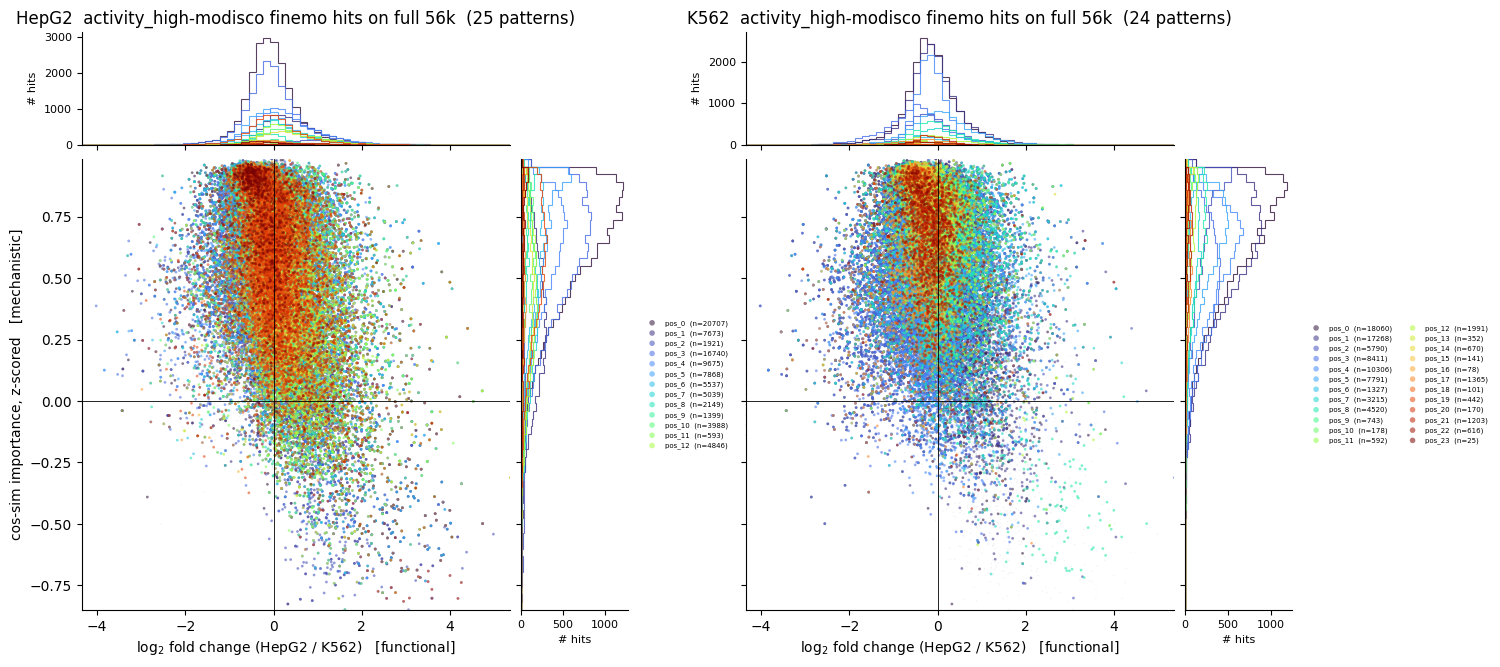

In [9]:
## activity-stratified modisco finemo hits across the full 56k library; one figure per stratum.
ACT_STRATA = ['activity_low', 'activity_mid', 'activity_high']
ACT_HITS   = lambda ct, s: os.path.join(REPO, 'genomic_targets/data/motif', ct, s, 'hits.tsv')

def hits_df_act(ct, s):
    h = pd.read_csv(ACT_HITS(ct, s), sep='\t', usecols=['peak_id', 'motif_name'])
    h['peak_id'] = h['peak_id'].astype(int)
    return h[h['peak_id'] < n]

for stratum in ACT_STRATA:
    fig = plt.figure(figsize=(17, 7.5))
    gs  = fig.add_gridspec(2, 6,
                           width_ratios=[4, 1, 0.9, 4, 1, 0.9],
                           height_ratios=[1, 4],
                           hspace=0.05, wspace=0.05)

    scatter_axes = []
    for col, ct in zip([0, 3], CTS):
        ax_main = fig.add_subplot(gs[1, col])
        ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
        ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

        ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                        edgecolors='none', rasterized=True)

        h = hits_df_act(ct, stratum)
        motifs = sorted(h['motif_name'].unique(), key=pat_key)
        cmap = plt.get_cmap('turbo')
        for i, mname in enumerate(motifs):
            ids = h.loc[h['motif_name'] == mname, 'peak_id'].values
            ids = ids[ids < n]
            m = np.zeros(n, dtype=bool); m[ids] = True; m &= fin
            if m.sum() < 1: continue
            c = cmap(i / max(1, len(motifs) - 1))
            ax_main.scatter(lfc[m], cossim[m], s=4, color=c, alpha=0.55,
                            edgecolors='none', rasterized=True,
                            label=f'{mname.replace("_patterns.pattern", "")}  (n={m.sum()})')
            if m.sum() >= 2:
                ax_top.hist(lfc[m],   bins=x_bins_h, color=c,
                            histtype='step', linewidth=0.8, alpha=0.8)
                ax_rt.hist(cossim[m], bins=y_bins_h, color=c,
                           histtype='step', linewidth=0.8, alpha=0.8,
                           orientation='horizontal')

        ax_main.axhline(0, color='k', lw=0.6); ax_main.axvline(0, color='k', lw=0.6)
        ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
        ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
        ax_main.legend(frameon=False, fontsize=5, loc='center left',
                       bbox_to_anchor=(1.30, 0.5), markerscale=2, ncol=2)
        for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

        ax_top.set_title(f'{ct}  {stratum}-modisco finemo hits on full 56k  '
                         f'({len(motifs)} patterns)')
        ax_top.set_ylabel('# hits', fontsize=8)
        ax_rt.set_xlabel('# hits', fontsize=8)
        plt.setp(ax_top.get_xticklabels(), visible=False)
        plt.setp(ax_rt.get_yticklabels(),  visible=False)
        ax_top.tick_params(axis='y', labelsize=8)
        ax_rt.tick_params(axis='x',  labelsize=8)
        for sp in ('top', 'right'):
            ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

        scatter_axes.append(ax_main)

    scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
    plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
    plt.show()